# Fitting Data 

## The Likelihood Function 

Suppose a probablity distribution for a random variable $x$ is parameterized by a set of parameters $\boldsymbol{\theta}$, $P(x|\boldsymbol{\theta})$. Up until now, when discussing probability distributions we have been assuming that the parameter(s), $\boldsymbol{\theta}$, are known and fixed, and that $P(x |\boldsymbol{\theta})$ gives the probability that specific values of $x$ will occur. As a concrete example, consider the normal distribution $\mathcal{N}(x |\mu, \sigma)$ where $\boldsymbol{\theta} = (\mu, \sigma)$, would represent the mean and standard deviation of the distribution. Now let us assume that the $\boldsymbol{\theta}$ parameters are not known. Instead, we are given a set of samples (i.e. measurements!) of $x$, and we wish to infer $\boldsymbol{\theta}$ from these samples. 

Let the measured value of $x$ be denoted by ${\hat x}$. If we evaluate the probability distribution at ${\hat x}$, then we define the likelihood function 
as
$$
L({\hat x}|\boldsymbol{\theta}) = P({\hat x}|\boldsymbol{\theta}). 
$$
Now in the expression above, ${\hat x}$ is a known fixed quantity (not a random variable), the elements of $\boldsymbol{\theta}$ are now the variables
of interest, which are the dependent variables of the likelihood function. 


## The Maximum Likelihood Principle

Given data points ${\hat x}$ drawn from a probability distribution $P(x|\boldsymbol{\theta})$, the **maximum likelihood principle states** that the best estimate of the parameters $\boldsymbol{\theta}$ are those which
maximize the likelihood function
$$
L({\hat x}|\boldsymbol{\theta}) = P({\hat x}|\boldsymbol{\theta}).
$$

## Example: Projectile Motion   

Imagine a ball moving in the vertical ($y$) direction under the influence of gravity. We know from basic
mechanics that the equation for its trajectory as a function of time is: 
$$
y_{\rm model}(t) = y_0 + v_{y0} t - \frac{1}{2} g t^2, 
$$
where $y_0$ is the initial height of the ball, $v_{y0}$ is its initial velocity, and $g$ is the acceleration due to the Earth's gravitational field (we are ignoring air resistance and the Coriolis acceleration). 

Consider that we have a set of noisy measurements of the position of the particle, $y(t_i)$, at different times, $t_i$, with standard deviation $\sigma_i$, and that the errors are Gaussian distributed. In other words
$$
y_i = y_{\rm model}(t) + \epsilon_i,
$$
where $\epsilon_i$ is a Gaussian distributed random variable representing the measurement error on the position $y(t_i)$ at time $t_i$.
In other words, 
$$
\epsilon_i \sim \mathcal{N}(\epsilon| 0, \sigma_i^2). 
$$

We would like to use the maximum likelihood principle to obtain the best estimate of the parameter vector 
$\boldsymbol{\theta}=(y_0,v_{y0}, g)$. Let's first generate some synthetic data for this example and make a plot to visualize the data. 

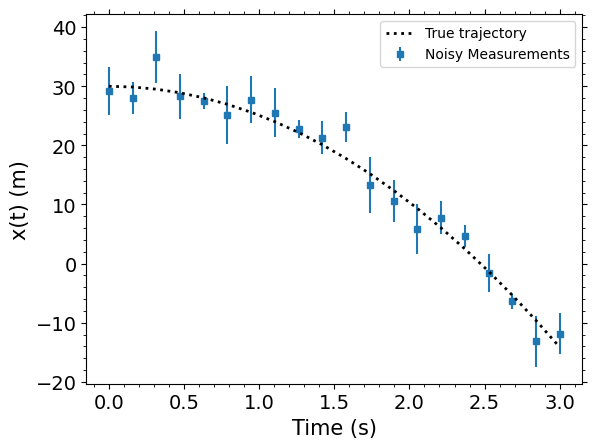

In [61]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy import stats
seed = 42
rng = np.random.default_rng(seed)

# Define the true value of the parameters
y_0 = 30.0 # m 
v_y0 = 0.0 # ball is thrown upwards at 5 m/s
g = 9.81 # m/s^2

# Let's suppose we have measurements every second
t_obs = np.linspace(0, 3, 20)
yoft_model = y_0 + v_y0 * t_obs - 0.5 * g * t_obs**2
# Generate some uniformly distributed random errors in the range [1, 10] 
sigma_y = rng.uniform(1.0, 5.0, len(t_obs))

# Generate standard Gaussian deviates with mu=0 and sigma=1
gauss_dev =rng.standard_normal(len(t_obs))
# Add the Gaussian deviates to the true values to get the noisy measurements
# after scaling the unit variance deviates by the measurement uncertainties
yoft_hat = yoft_model + sigma_y * gauss_dev

# Make a plot of the data with error bars
fig, ax = plt.subplots()
ax.errorbar(t_obs, yoft_hat, yerr=sigma_y, fmt='s', markersize=5, label='Noisy Measurements')
ax.plot(t_obs, yoft_model, 'k:', linewidth=2, zorder=10, label='True trajectory')
ax.set_xlabel('Time (s)', fontsize=15)
ax.set_ylabel('x(t) (m)', fontsize=15)
ax.legend()

# Some tick mark things
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True, labelbottom=True, labelsize=14)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

Now that we have examined the data, we will derive an expression for the likelihood function $L(\mathbf{y}| \boldsymbol{\theta}, \boldsymbol{\sigma})$, where  $\mathbf{\hat y} = ({\hat y}(t_1), {\hat y}(t_2), \cdots, {\hat y}(t_n))$ is the vector of measurements, $\boldsymbol{\sigma}= (\sigma(t_1), \sigma(t_2), \cdots, \sigma(t_n)$ is the vector of standard deviations, and $\boldsymbol{\theta} = (y_0, v_{y0}, g)$ is the vector of parameters. To determine the likelihood function,  we need to construct a probabalistic model for the measurement process and evaluate it at our measurements $\mathbf{{\hat y}}$. This is easy to do since we know the measurement errors are Gaussian distributed. 
Thus the likelihood function is
<a id='eqn:lhood'></a>
$$
L(\mathbf{y}| \boldsymbol{\theta}, \boldsymbol{\sigma}) = \prod_i^n \frac{1}{\sqrt{2\pi}\sigma_i}\exp\left\{-\frac{\left[y_i - (y_0 + v_{y0}t + gt^2)\right]^2}{2\sigma_i^2}\right\} =   \prod_i^n \frac{1}{\sqrt{2\pi}\sigma_i}\exp\left\{-\frac{\left[y_i - y_{\rm model}(t_i | \boldsymbol{\theta})\right]^2}{2\sigma_i^2}\right\} \tag{1}
$$
It is worth pausing to understand what we are doing here. The likelihood function expresses the probability of measuring the data ${\hat y}(t_i)$ given a value of the parameters $\boldsymbol{\theta} = (y_0, v_{y0}, g)$. The product in the likelihood function is a consequence of the fact that the *measurements are all stastistically independent*, i.e. 
$$ 
L(\mathbf{y}| \boldsymbol{\theta}, \boldsymbol{\sigma}) = \mathcal{N}(y_1| \mu_1, \sigma_1)\mathcal{N}(y_2| \mu_2, \sigma_2)\cdots \mathcal{N}(y_n| \mu_n, \sigma_n),
$$
where $\mu_i = y_{\rm model}(t_i | \boldsymbol{\theta}) \equiv y_0 + v_{y0}t_i + gt_i^2$.  This is in fact a consequence of what we learned previously for the joint distribution of statistically independent random variables
$$
P(x_1, x_2, \cdots, x_n) = P(x_1)P(x_2)\cdots P(x_n).
$$

We can further simplify eqn.(<a href="#eqn:lhood">1</a>) by noting that 
<a id='eqn:lhood_chi2'></a>
$$
\begin{align}
L(\mathbf{y}| \boldsymbol{\theta}, \boldsymbol{\sigma}) =&  \frac{1}{\sqrt{2\pi}\sigma_1}\exp\left\{-\frac{\left[y_1 - y_{\rm model}(t_1 | \boldsymbol{\theta})\right]^2}{2\sigma_1^2}\right\}\frac{1}{\sqrt{2\pi}\sigma_2}\exp\left\{-\frac{\left[y_2 - y_{\rm model}(t_2 | \boldsymbol{\theta})\right]^2}{2\sigma_2^2}\right\}\times \cdots \times \frac{1}{\sqrt{2\pi}\sigma_n}\exp\left\{-\frac{\left[y_n - y_{\rm model}(t_n | \boldsymbol{\theta})\right]^2}{2\sigma_n^2}\right\}\nonumber\\
=& \frac{1}{(2\pi)^{n/2}\sigma_1\sigma_2\cdots\sigma_n}\exp\left\{-\frac{\left[y_1 - y_{\rm model}(t_1 | \boldsymbol{\theta})\right]^2}{2\sigma_1^2} - \frac{\left[y_2 - y_{\rm model}(t_2 | \boldsymbol{\theta})\right]^2}{2\sigma_2^2} - \cdots - \frac{\left[y_n - y_{\rm model}(t_n | \boldsymbol{\theta})\right]^2}{2\sigma_n^2}\right\}\nonumber\\
=& \frac{1}{(2\pi)^{n/2}\sigma_1\sigma_2\cdots\sigma_n} \exp\left\{-\frac{\chi^2}{2}\right\}, \tag{2}
\end{align}
$$
where in the last step we used the property of the exponential function, i.e. $\exp(a)\exp(b) = \exp(a+b)$, and defined the **chi-squared** statistic
$$
\chi^2(\boldsymbol{\theta}) \equiv \sum_{i=1}^n \left[\frac{y_i-y_{\rm model}(t_i | \boldsymbol{\theta})}{\sigma_i}\right]^2.
$$

It is convenient and common practice to work with the logarithm of the likelihood. This is because the the likelihood function is typically a product of many probabilities (of making each measurement in a dataset) which are in general numbers less than one. Furthermore, in the outskirts of the probability distributions, the probability values can be very small and can underflow the numerical precision of the computer. Taking the logarithm can better accomodate a large dynamic range, and turns the multiplications of small numbers into additions, which  are numerically more stable.  Taking the logarithm of the likelihood function, we have
<a id='eqn:lhood_chi2'></a>
$$
\ln L(\mathbf{y}| \boldsymbol{\theta}, \boldsymbol{\sigma}) = -\frac{n}{2}\ln(2\pi) - \frac{1}{2}\sum_{i=1}^n \ln(\sigma_i^2) - \frac{\chi^2}{2}. \tag{3}
$$

Based on the  form of eqn.(<a href="#eqn:lnL">3</a>), it is clear that **maximizing the likelihood** is equivalent to **minimizing the chi-squared**. This is the basis of the idea of **$\chi^2$ minimization** which is a common approach to fitting data across the physical sciences.



In [62]:
# Do the scipy optimize example here

## Bayesian Statisitcs 

Previously we introduced Bayes' theorem
$$
P(y|x) = \frac{P(x|y)P(y)}{P(x)}. 
$$

Now let's imagine that $x$ is the outcome of an experiment represented by some data we have collected. Let $y=\theta$ be a physical parameter of interest (e.g. the value of a fundamental constant, the distance to a galaxy, or the mass of a particle) that 
we would like to measure from our data in the context of a physical model.  Then we can write Bayes' theorem as
<a id='eqn:bayes'></a>
$$
P(\theta|x) = \frac{P(x|\theta)P(\theta)}{P(x)}. \tag{1}
$$
Since the conditional distribution, $P(x|\theta)$, states that the occurrence of $x$  is conditioned on the occurence of $\theta$, 
we can write the total probability of $x$ occuring as the integral over all possible values of $\theta$
$$
P(x) = \int P(x|\theta)P(\theta)d\theta. 
$$
In other words, the quantity $P(x)$ in the denominator of eqn.(<a href="#bayes">1</a>)
can be thought of as the normalization constant for the distribution $P(\theta|x)$ on the left-hand side
<a id='eqn:bayes2'></a>
$$
P(\theta|x) = \frac{P(x|\theta)P(\theta)}{P(x)} = \frac{P(x|\theta)P(\theta)}{\int P(x|\theta)P(\theta)d\theta}, 
$$
in that it ensures that $\int P(\theta|x)d\theta = 1$.



The fundamental objects in Bayesian statistics are probability distributions. The equation above describes how probability distributions evolve as new data $x$ becomes available. To make this more clear, let's modify our notation slightly
$$
P(\theta|x) = \frac{L(x|\theta)Pr(\theta)}{\int L(x|\theta)Pr(\theta)d\theta}.  \tag{2}
$$
- $L(x|\theta)$ is the **likelihood function**, which is the probability of observing the data $x$ given the parameter $\theta$.
- $Pr(\theta)$ is the **prior distribution**, which is the probability of the parameter $\theta$ based on existing knowledge before acquiring the
data $x$.
- $P(\theta|x)$ is the **posterior  distribution**, which is the revised probability for $\theta$ given the combination of our prior knowledge and the new data $x$ that we acquired. 

We don't have to worry about the normalization of the likelihood, $L(x|\theta)$, or the product $L(x|\theta)Pr(\theta)$ in the numerator, since any constant factors are going cancel in the division by the normalization factor in the denominator.

### The Flow of Information

Bayesian inference provides a well-defined quantitative logical framework for synthesizing information about the world we live in. 
Specifically, it tells us how merge new information (the new data $x$) with existing knowledge (the prior) to yield new probability distributions (the posterior). 

There are several important features of Bayesian statistics:
1. The key ingredients are the $\theta$ dependent probability distributions in the numerator of eqn.(<a href="#bayes2">2</a>):
   * $Pr(\theta)$: we are required to explicitly adopt a prior probability distribution that reflects our existing knowledge of $\theta$. 
   *  $L(x|\theta)$: we are required to construct a **generative probablistic model** for the measurement process, which is the likelihood function, $L(x|\theta)$. 
  
2. Any amount of new data $x$, even a single measurement, can be used to revise the probability distribution for $\theta$, yielding a new posterior $P(\theta|x)$. 
   
3. There is no need to pre-specify the end point of an experiment or investigation. Data can be incorporated as they become available. Essentially, one replaces the prior $Pr(\theta)$ with the posterior $P(\theta|x)$, and then obtains new data, cycling through the inference loop as often as desired. This is illustrated by the flow chart below. 


<div style="text-align: left">
    <img src="figures/bayesian_flow.png" style="width: 800px; margin-left: 80px;"/>
</div>


### Example: The Distance to a Galaxy

An astronomical catalog indicates that the distance to a galaxy is $D_0 = 11 \pm 4$ Mpc. Here Mpc is an astronomical distance units that stands for mega-parsecs, i.e. a million parcsecs, where $1~{\rm pc} = 3.086 \times 10^{16}~{\rm m}$. It is understood that the quoted uncertainty is the standard deviation, $\sigma_0 = 4~{\rm Mpc}$, of a Gaussian distribution that describes our current knowledge of the distance. Suppose we make a new measurement of the distance to this galaxy, $D_1 = 7.3\pm 2~{\rm Mpc}$, where again the measurement errors are Gaussian distributed and $\sigma_1=0.1~{\rm Mpc}$.  What is the revised probability distribution for the distance to the galaxy in light of our new measurement?



The problem states that both our prior knowledge and the new  measurement are described by Gaussians.  To clarify the notation: 
- $D$ denotes the random variable representing the unknown distance to the galaxy ($\theta$ in the notation of Bayes theorem). 
- $D_0$ is the prior distance (with standard deviation $\sigma_0$) to the galaxy. 
- $D_1$ is the new measurement (with standard deviation $\sigma_1$) of the distance (the data $x$ in the notation of Bayes theorem). 

Since the probability distributions are all Gaussian we can write
$$
Pr(D) = \frac{1}{\sqrt{2\pi}\sigma_0}\exp\left[-\frac{(D-D_0)^2}{2\sigma_0^2}\right]
$$
and 
$$
L(D_1|D) = \frac{1}{\sqrt{2\pi}\sigma_1}\exp\left[-\frac{(D_1-D)^2}{2\sigma_1^2}\right]. 
$$

The unnormalized posterior distribution is then 
$$
P(D |D_1) \propto L(D_1|D)Pr(D) = \frac{1}{\sqrt{2\pi}\sigma_1}\exp\left[-\frac{(D_1-D)^2}{2\sigma_1^2}\right]\frac{1}{\sqrt{2\pi}\sigma_0}\exp\left[-\frac{(D-D_0)^2}{2\sigma_0^2}\right].
$$

It is easy to show that the product of two Gaussian probability distributions is also a Gaussian, so we can rewrite the posterior as
$$
P(D |D_1) = \frac{1}{\sqrt{2\pi}\sigma_\ast}\exp\left[-\frac{(D-D_\ast)^2}{2\sigma_\ast^2}\right], 
$$
where 
<a id='eqn:mean'></a>
$$
D_\ast = \frac{w_0 D_0 + w_1 D_1}{w_0 + w_1} = \frac{\sigma_1^2 D_0 + \sigma_0^2 D_1}{\sigma_0^2 + \sigma_1^2}, \tag{3}
$$
and 
<a id='eqn:sigma'></a>
$$
\sigma_\ast^2 = \frac{1}{w_0 + w_1} =  \frac{\sigma_0^2 \sigma_1^2}{\sigma_0^2 + \sigma_1^2} = \sigma_0^2\left(\frac{\sigma_1^2}{\sigma_0^2 + \sigma_1^2}\right). \tag{4}
$$
and we defined the *weights* $w_0 = 1/\sigma_0^2$ and $w_1 = 1/\sigma_1^2$.

Because the posterior is a Gaussian, the mean value and standard deviation of the distance to the galaxy, $D$, can be extracted by 
inspection, i.e. 
$$
\langle D\rangle \pm \sigma_D = D_\ast \pm \sigma_\ast. 
$$
Moreover, the expressions for $D_\ast$ and $\sigma_\ast$ are consistent with our intuition. 

The mean value  is a weighted average of the prior distance and the new measurement, where the weights are inversely proportional to their respective variances.   In other words, we are *optimally combining** the information -- if the new measurement is very precise, then its contribution will dominate the posterior mean, whereas if the prior is very precise, then the prior dominates the posterior mean.   
The standard deviation of the posterior is the harmonic mean of the standard deviations of the prior and the new measurement. 
From the last equaltiy of eqn.(<a href="#sigma">2</a>), it can be seen that the standard deviation of the posterior is always less than the standard deviation of the prior, as it should be, since given new information, we should be more certain about the value of the parameter.

It is instructive to consider limit of the expressions for $D_\ast$ and $\sigma_\ast$ in eqns.(<a href="#mean">3</a>) and (<a href="#sigma">4</a>) $\sigma_1 \ll \sigma_0$ ($w_1  \gg w_0$), i.e. where the new measurement is far more precise than our prior knowledge. This is the limit of an **uninformative prior**, since if $\sigma_1 \ll \sigma_0$, then the prior distribution, $Pr(D)$ is becoming very broad relative to an 
extremely narrowly peaked likelihood, $L(D_1|D)$. It is easy to see that in this limit, 
$$
D_\ast \approx D_1, \quad \sigma_\ast \approx \sigma_1, 
$$
which is to say that the posterior mean and standard deviation are completey dominated by the new measurement. This is the behavior we expect. 

D_star=8.0 +- 1.8 Mpc


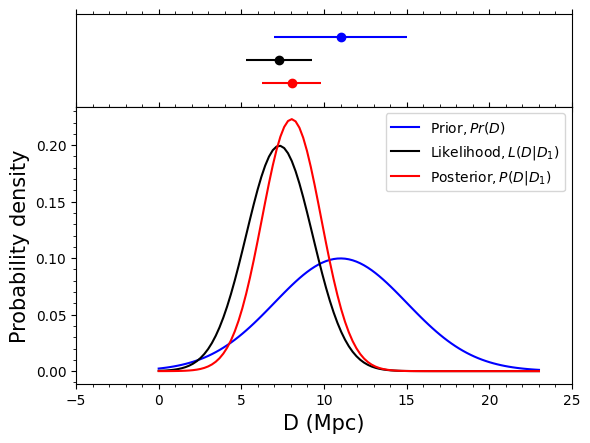

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# Parameters for the prior
D_0 = 11.0  # Prior mean, Mpc
sigma_0 = 4.0 # Prior standard deviation, Mpc
# Parameters for the likelihood 
D_1 = 7.3 # Measured distance, Mpc
sigma_1 = 2.0 # Measurement uncertainty, Mpc
# Parameters for the posterior
w_0 = 1/sigma_0**2
w_1 = 1/sigma_1**2
D_star = (w_0*D_0 + w_1*D_1)/(w_0 + w_1)
sigma_star = 1/np.sqrt(w_0 + w_1)

print(f"D_star={D_star:.1f} +- {sigma_star:.1f} Mpc")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 3], 'hspace': 0})

# Plot error bars for the prior, measurement, and posterior in the upper subplot
ax1.errorbar(D_0, 3, xerr=sigma_0, fmt='o', color='blue')
ax1.errorbar(D_1, 2, xerr=sigma_1, fmt='o', color='black')
ax1.errorbar(D_star, 1, xerr=sigma_star, fmt='o', color='red')
ax1.set_ylim(0, 4)
ax1.set(yticks=[])

# Now plot the prior, the likelihood, and the posterior
D = np.linspace(0, 23, 101)
Pr = stats.norm.pdf(D, D_0, sigma_0)
L = stats.norm.pdf(D, D_1, sigma_1)
P = stats.norm.pdf(D, D_star, sigma_star)
ax2.plot(D, Pr, color='blue', label=r'${\rm Prior}, Pr(D)$')
ax2.plot(D, L, color='black', label=r'${\rm Likelihood}, L(D|D_1)$')
ax2.plot(D, P, color='red', label=r'${\rm Posterior}, P(D|D_1)$')

# Add minor ticks
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())

ax2.set_ylabel('Probability density', fontsize=15)
ax2.set_xlabel('D (Mpc)', fontsize=15)
ax2.legend()
ax2.tick_params(which='both', bottom=True, top=True, labelbottom=True)

# Get x-axis tick locations from ax2 and set them for ax1
ax1.set_xticks(ax2.get_xticks())
ax1.tick_params(which='both', bottom=True, top=True, labelbottom=False)
plt.show()

## Example: Projectile Motion  Bayesian Inference (update)


Now that we have examined the data, we will proceed to use Bayesian statistics to estimate the unknown velocity of the particle, $v_0$.
Let's assume that we do not have any prior information on, $v_0$, so we will adopt an uninformative constant prior probability, $Pr(v_0) = {\rm const}$. For the likelihood function, we need to construct a probabalistic model for the measurement process. This is easy to do since we know the measurements errors are Gaussian distributed. 
$$
L(\mathbf{x}| v_0, \boldsymbol{\sigma}) = \mathcal{N}(x_1| \mu_1, \sigma_1)\mathcal{N}(x_2| \mu_2, \sigma_2)\cdots \mathcal{N}(x_n| \mu_n, \sigma_n), 
$$
where $\mu_i = x_0 + v_0 t_i$.  It is worth pausing to understand what we are doing here. The likelihood function expresses the probability of measuring the data $x(t_i)$ given a value of the parameter $v_0$. The product in the likelihood function is a consequence of the fact that the *measurements are all stastistically independent*.  This is in fact a consequence of what we learned previously for the joint distribution of statistically independent random variables
$$
P(x_1, x_2, \cdots, x_n) = P(x_1)P(x_2)\cdots P(x_n).
$$
Thus the likelihood function is
$$
L(\mathbf{x}| v_0, \boldsymbol{\sigma}) = \prod_i^n \frac{1}{\sqrt{2\pi}\sigma_i}\exp\left[-\frac{(x_i - (x_0 + v_0 t_i)^2}{2\sigma_i^2}\right].  
$$

It is convenient and common practice to work with the logarithm of the posterior distribution and the logarithm of the likelihood. This is because the the likelihood function is typically a product of many probabilities (of making each measurement in a dataset) which are in general numbers less than one. Furthermore, in the outskirts of the probability distributions, the probability values can be very small and can underflow the numerical precision of the computer. Taking the logarithm can better accomodate a large dynamic range, and turns the multiplications of small numbers into additions, which  are numerically more stable.  Taking the logarithm of the likelihood function, we have
$$
\ln L(\mathbf{x}| v_0, \boldsymbol{\sigma}) = -\frac{1}{2}\sum_i^n \left\{\log(2\pi\sigma_i^2) + \frac{[x(t_i) - (x_0 + v_0 t_i)]^2}{\sigma_i^2}\right\}.
$$

Since the prior is constant, the log of the posterior is simply the log of the likelihood function plus a constant, but we can always drop a multiplicative constant in the posterior (additive constantin the logarithm) since this can be absorbed into the
normalization constant in Bayes' theorem. 

So we can write the log of the posterior as
$$
\ln P(v_0|\mathbf{x}) = \ln L(\mathbf{x}| v_0, \boldsymbol{\sigma}) + {\rm const}.
$$



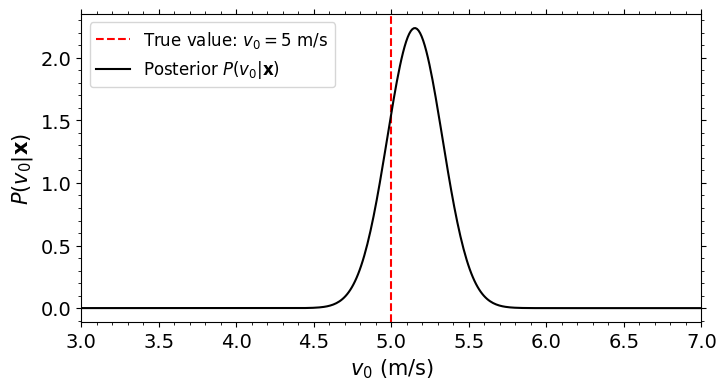

In [4]:
from scipy import stats
from scipy import integrate

# Define the likelihood function
def log_likelihood(v_0, x_obs, sigma_x, x_0, t_obs):
    """
    Compute the log of the likelihood for a given value of v_0
    
    Parameters
    ----------
    v_0 : float
        The value of the initial velocity parameter in m/s
    x_obs : array_like
        The observed positions data at each time in m. 
    sigma_x : array_like
        The uncertainties on the position measurements at each time in m. 
    x_0 : float
        The initial position in m. We assume this is known exactly.
    t_obs : array_like
        The time of each position measurement in s. We assume this is known exactly.
        
    Returns
    -------
    lnL : float
        The log of the likelihood evaluated at v_0 
    """
    
    # The mean of the Gaussian distribution for each of the observed positions    
    xoft_model = x_0 + v_0 * t_obs
    # This is the vector of log-likelihoods for each data point
    lnL_vec = stats.norm.logpdf(x_obs, loc=xoft_model, scale=sigma_x)
    # Sum the log-likelihoods to get the total log-likelihood
    return np.sum(lnL_vec)

# Evaluate the likelihood as a function of v_0 on a finely spaced grid
v_0_values = np.linspace(0, 10, 1000)
# This list comprehension is compact way to write a for loop, evaluating the likelihood at each v_0
lnL_values = np.array([log_likelihood(v_0, xoft, sigma_x, x_0, t_obs) for v_0 in v_0_values])
# Our prior is flat, so the posterior is proporitional to the prior. 
# We will will normalize in a moment, but we subtract the maximum value of the log-likelihood
# to avoid taking the expoential of very large numbers. You can always add or subtract a constant from lnL
P_unnorm = np.exp(lnL_values - np.max(lnL_values))
# Now perform the normalization by integrating the tabulated unnormalized posterior using Simpson's rule
P_norm = integrate.simpson(P_unnorm, v_0_values)
# This is the final normalized posterior
Pofv0 = P_unnorm/P_norm

# Plot the resulting posterior distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.axvline(v_0, color='r', linestyle='--', label=r'True value: $v_0=5~{\rm m/s}$')
ax.plot(v_0_values, Pofv0, color='k', label=r'Posterior $P(v_0|\mathbf{x})$')
ax.set_xlabel(r'$v_0~({\rm m/s})$', fontsize=15)
ax.set_ylabel(r'$P(v_0|\mathbf{x})$', fontsize=15)
ax.set_xlim(3, 7)

# Some tick mark things
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True, labelbottom=True, labelsize=14)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend(loc='upper left', fontsize=12)

